In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_squared_error
)

In [70]:
df = pd.read_csv('src/data/training/processed/final_training_data.csv')

In [59]:
target_cols = df.filter(regex='^(dn__|ul__|mv__|madrid__|ep__|cb__|ob__|ab__)').columns

missing_or_zero = df[target_cols].isna() | (df[target_cols] == 0)

missing_fraction = missing_or_zero.mean(axis=1)

df = df[missing_fraction <= 0.8].copy()

In [71]:
y = df[['t__ccf']].clip(lower=0, upper=2)
X = df[['ob__avg_util_ref']]

In [72]:
bins = [0, 0.2, 0.4, 0.6, 0.8]
labels = ['<=20%', '20% to 40%', '40% to 60%', '60% to 80%']

df['util_bin'] = pd.cut(df['ob__avg_util_ref'], bins=bins, labels=labels, include_lowest=True)

dummies = pd.get_dummies(df['util_bin'])

X = pd.concat([df[['ob__avg_util_ref']], dummies], axis=1)
X = X.drop(columns=['ob__avg_util_ref'])
X = X.astype(int)


In [73]:
X

,<=20%,20% to 40%,40% to 60%,60% to 80%
0,0,0,0,0
1,0,0,0,1
2,0,0,0,0
3,0,0,0,1
4,0,0,0,1
...,...,...,...,...
15529,1,0,0,0
15530,0,0,0,0
15531,0,0,0,0
15532,0,0,0,0


In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [75]:
lin_reg = LinearRegression().fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

In [76]:
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)

model = sm.OLS(y_train, X_train_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 t__ccf   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     10.34
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           2.34e-08
Time:                        14:13:17   Log-Likelihood:                -9183.6
No. Observations:               10873   AIC:                         1.838e+04
Df Residuals:                   10868   BIC:                         1.841e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6954      0.008     86.763      0.0

In [77]:
X_test_sm = sm.add_constant(X_test)
y_pred = model.predict(X_test_sm)

In [78]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.3132696975533173


In [79]:
y_pred.mean()

np.float64(0.6688679982804556)

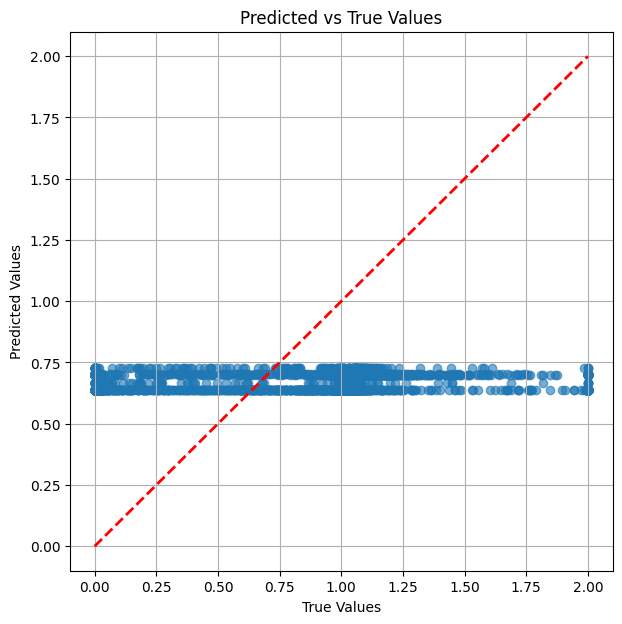

In [68]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, linestyle='--')  # y=x reference line
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True Values")
plt.grid(True)
plt.show()

In [47]:
y_pred

10222    0.542665
12897    0.644206
11932    0.644206
3935     0.644206
13241    0.567615
           ...   
13025    0.542665
4120     0.616340
1221     0.644206
11744    0.542665
52       0.644206
Length: 4566, dtype: float64